# Regression Preparation

In [1551]:
import os
import pandas as pd
import numpy as np

os.chdir('/Users/janlinzner/Projects/Master-Thesis-Spatial-Proximity-Venture-Capital')

In [1552]:
data = pd.read_csv('data/sets-for-r/companies_seed.csv')

In [1553]:
unique_countries = data['Headquarters Country'].unique()
print(unique_countries)

['United Kingdom' 'France' 'Germany' 'Austria' 'Denmark' 'The Netherlands'
 'Switzerland' 'Italy' 'Czech Republic' 'Latvia' 'Spain' 'Finland'
 'Norway' 'Estonia' 'Ireland' 'Belgium' 'Greece' 'Portugal' 'Hungary'
 'Poland' 'Slovakia (Slovak Republic)' 'Lithuania']


In [1554]:
selected_vars = [
    "Company ID",
    "Organization Name", "Founded Year", "First Seed Year", "Organization Name URL",
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Norway", "Poland", "Portugal", "Slovakia (Slovak Republic)", "Spain", "Switzerland", "The Netherlands", "United Kingdom",
    "Headquarters Country",
    "Success",
    "Exit Binary",
    "Funding Success",
    "Years to Exit",
    "Minimum Seed VC Distance",
    "Number of Founders",
    "Hub Binary",
    "Distance to Hub",
    "B2B Binary",
    "Startups Within 50km",
    "VCs Within 50km",
    "Share Successful Startups in Environment",
    "Top University Count",
    "Top University Ecosystem Binary", 
    "Number Seed Rounds",
    "Avg Seed Investor Distance",
    "Avg Seed Investor Pairwise Distance",
    "Average Seed Investors Portfolio Organizations",
    "Number Seed Investors",
    "Regional Seed Investor Binary",
    "Overregional Seed Investor Binary",
    "Avg Age of Seed Investors",
    "Avg Exits of Seed Investors",
    "Specific VC in Seed Binary",
    "Target VC in Seed Binary",
    "Hub VC in Seed Binary",
    "Accelerator Funding Binary",
    "Angel Group Funding Binary",
    "Micro VC Funding Binary",
    "Corporate Venture Capital Funding Binary",
    "Homecountry Investor in Seed Binary",
    "Seed Investor Same City",
    "Seed Lead Investor Same City",
    "Years to Seed",
    "Total Seed Funding (M)",
    "Energy",
    "Materials",
    "Industrials",
    "Consumer Discretionary",
    "Consumer Staples",
    "Health Care",
    "Financials",
    "Information Technology",
    "Communication Services",
    "Utilities",
    "Real Estate",
    "Other",
    "Last Equity Funding Type",
    "Latitude",
    "Longitude"
    
]

data = data[selected_vars]

In [1555]:
missing_values_analysis = data.isnull().sum().reset_index()
missing_values_analysis.columns = ['Variable', 'Missing Values']
missing_values_analysis['Non-Missing Values'] = data.shape[0] - missing_values_analysis['Missing Values']
missing_values_analysis.sort_values(by='Missing Values', ascending=False, inplace=True)


In [1556]:
country_columns = [
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Hungary",
    "Ireland", "Italy", "Norway", "Poland", "Portugal", "Spain", "Switzerland", "The Netherlands", "United Kingdom"
]

In [1557]:
countries = [
    "Austria", "Belgium", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Norway", "Poland", "Portugal", "Slovakia (Slovak Republic)", "Spain",
    "Switzerland", "The Netherlands", "United Kingdom"
]

country_counts = data[countries].sum().reset_index()
country_counts.columns = ['Country', 'Number of Companies']

In [1558]:
valid_countries = country_counts[country_counts['Number of Companies'] >= 500]['Country'].tolist()

data = data[data[valid_countries].any(axis=1)]

In [1559]:
columns_to_drop = [col for col in countries if col not in valid_countries]
data = data.drop(columns=columns_to_drop)

In [1560]:
data = data.dropna(subset=['Number of Founders'])

In [1561]:
data['Hub Binary'] = data['Hub Binary'].astype(bool)

Age

In [1562]:
data['Age'] = data['First Seed Year'] - data['Founded Year']

In [1563]:
data['Age'] = data['Age'].apply(lambda x: max(x, 0))

In [1564]:
selected_vars_1 = [
    "Company ID",
    "Organization Name", 
    "Founded Year", 
    "Organization Name URL",
    "Headquarters Country",
    "Number of Founders",
    "Age",
    "Hub Binary",
    "B2B Binary",
    "Number Seed Rounds",
    "Avg Seed Investor Distance",
    "Avg Seed Investor Pairwise Distance",
    "Average Seed Investors Portfolio Organizations",
    "Number Seed Investors",
    "Avg Age of Seed Investors",
    "Specific VC in Seed Binary",
    "Target VC in Seed Binary",
    "Hub VC in Seed Binary",
    "Accelerator Funding Binary",
    "Angel Group Funding Binary",
    "Micro VC Funding Binary",
    "Corporate Venture Capital Funding Binary",
    "Homecountry Investor in Seed Binary",
    "Seed Investor Same City",
    "Seed Lead Investor Same City",
    "Total Seed Funding (M)",
    "Energy",
    "Materials",
    "Industrials",
    "Consumer Discretionary",
    "Consumer Staples",
    "Health Care",
    "Financials",
    "Information Technology",
    "Communication Services",
    "Utilities",
    "Real Estate",
    "Other",
    "Success",
    "Exit Binary",
    "Funding Success",
    "Years to Exit",
    "Minimum Seed VC Distance",
    "Last Equity Funding Type",
    "Latitude",
    "Longitude"
]

data = data[selected_vars_1]

Network

In [1565]:
company_counts_per_country = data['Headquarters Country'].value_counts()
print(company_counts_per_country)

Headquarters Country
United Kingdom     3381
Germany            1557
France             1040
Spain               763
The Netherlands     488
Name: count, dtype: int64


In [1566]:
seed_help = pd.read_csv('data/sets-for-r/seed_help.csv')

In [1567]:
seed_help = seed_help[seed_help['Company ID'].isin(data['Company ID'])]

In [1568]:
'''
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
from collections import defaultdict
from tqdm.auto import tqdm

# ───────────────────────────────────────────────────────────────────────────────
# 0) YOUR INPUTS
# ───────────────────────────────────────────────────────────────────────────────
# seed_help: DataFrame with columns ['Investor ID', 'Company ID', 'Country']
# data:       DataFrame with columns ['Company ID', 'Headquarters Country', ...]
#
# e.g.:
# seed_help = pd.read_csv('seed_help.csv')
# data       = pd.read_csv('company_data.csv')

# ───────────────────────────────────────────────────────────────────────────────
# 1) BUILD THE BIPARTITE GRAPH B
# ───────────────────────────────────────────────────────────────────────────────
B = nx.Graph()

investors = seed_help['Investor ID'].unique()
companies = data['Company ID'].unique()

# add nodes with a bipartite flag
B.add_nodes_from(investors, bipartite=0)
B.add_nodes_from(companies, bipartite=1)

# add edges: one per investment event
for inv, comp in tqdm(
    zip(seed_help['Investor ID'], seed_help['Company ID']),
    total=len(seed_help),
    desc="Adding investor–company edges"
):
    B.add_edge(inv, comp)

# ───────────────────────────────────────────────────────────────────────────────
# 2) ANNOTATE NODES WITH HOME-COUNTRY
# ───────────────────────────────────────────────────────────────────────────────
# map Company ID → Headquarters Country
company_country_map = data.set_index('Company ID')['Headquarters Country'].to_dict()
# map Investor ID → Country
investor_country_map = (
    seed_help
      .groupby('Investor ID')['Country']
      .first()
      .to_dict()
)

nx.set_node_attributes(B, company_country_map, 'country')
nx.set_node_attributes(B, investor_country_map,  'country')

# ───────────────────────────────────────────────────────────────────────────────
# 3) PROJECT TO ONE-MODE GRAPHS
# ───────────────────────────────────────────────────────────────────────────────
# co-startup network: companies linked by shared investors
C_comp = bipartite.weighted_projected_graph(B, companies)
# co-investor network: investors linked by shared startups
C_inv  = bipartite.weighted_projected_graph(B, investors)

# carry over country attribute
nx.set_node_attributes(C_comp, company_country_map, 'country')
nx.set_node_attributes(C_inv,  investor_country_map, 'country')

# ───────────────────────────────────────────────────────────────────────────────
# 4) DEFINE EIGENVECTOR FALLBACK & CENTRALITY FUNCTIONS
# ───────────────────────────────────────────────────────────────────────────────
def compute_eigen(g):
    try:
        # try power iteration with more iterations
        return nx.eigenvector_centrality(
            g,
            max_iter=1000,
            tol=1e-6,
            weight='weight'
        )
    except nx.PowerIterationFailedConvergence:
        try:
            # fallback to the NumPy-based solver
            return nx.eigenvector_centrality_numpy(g, weight='weight')
        except Exception:
            # last resort: zero out centrality
            return {n: 0.0 for n in g}

cent_funcs = {
    'Degree':      nx.degree_centrality,
    'Betweenness': lambda g: nx.betweenness_centrality(g, normalized=True, weight=None),
    'Closeness':   nx.closeness_centrality,
    'Eigenvector': compute_eigen,
}

# ───────────────────────────────────────────────────────────────────────────────
# 5) HELPER FOR PER-COUNTRY CENTRALITIES
# ───────────────────────────────────────────────────────────────────────────────
def per_country_centralities(G, cent_funcs, desc):
    """
    G:        Graph with node attribute 'country'
    cent_funcs: dict[name → function(subgraph) → {node: score}]
    desc:     description for tqdm
    """
    results = { name: {} for name in cent_funcs }
    countries = set(nx.get_node_attributes(G, 'country').values())

    for country in tqdm(countries, desc=desc):
        nodes = [n for n, d in G.nodes(data=True) if d.get('country') == country]
        if len(nodes) < 2:
            for name in cent_funcs:
                for n in nodes:
                    results[name][n] = 0.0
            continue

        sub = G.subgraph(nodes)
        for name, func in cent_funcs.items():
            scores = func(sub)
            for n, v in scores.items():
                results[name][n] = v

    return results

# ───────────────────────────────────────────────────────────────────────────────
# 6) GLOBAL CENTRALITIES (OPTIONAL)
# ───────────────────────────────────────────────────────────────────────────────
global_comp = {
    'Degree_Global':     nx.degree_centrality(C_comp),
    'Betweenness_Global':nx.betweenness_centrality(C_comp, normalized=True, weight=None),
    'Closeness_Global':  nx.closeness_centrality(C_comp),
    'Eigenvector_Global':nx.eigenvector_centrality(C_comp, max_iter=1000, tol=1e-6, weight='weight'),
}

global_inv = {
    'Degree_Global':     nx.degree_centrality(C_inv),
    'Betweenness_Global':nx.betweenness_centrality(C_inv, normalized=True, weight=None),
    'Closeness_Global':  nx.closeness_centrality(C_inv),
    'Eigenvector_Global':nx.eigenvector_centrality(C_inv, max_iter=1000, tol=1e-6, weight='weight'),
}

# ───────────────────────────────────────────────────────────────────────────────
# 7) COMPUTE PER-COUNTRY CENTRALITIES
# ───────────────────────────────────────────────────────────────────────────────
comp_cents = per_country_centralities(C_comp, cent_funcs, desc="Companies by country")
inv_cents  = per_country_centralities(C_inv,  cent_funcs, desc="Investors by country")

# ───────────────────────────────────────────────────────────────────────────────
# 8) ASSEMBLE & MERGE BACK
# ───────────────────────────────────────────────────────────────────────────────
# Companies DataFrame
comp_df = pd.DataFrame({'Company ID': list(C_comp.nodes())})
for nm, scores in global_comp.items():
    comp_df[nm] = comp_df['Company ID'].map(scores)
for nm, scores in comp_cents.items():
    comp_df[f"{nm}_HomeCountry"] = comp_df['Company ID'].map(scores)

data = data.merge(comp_df, on='Company ID', how='left')

# Investors DataFrame
inv_df = pd.DataFrame({'Investor ID': list(C_inv.nodes())})
for nm, scores in global_inv.items():
    inv_df[nm] = inv_df['Investor ID'].map(scores)
for nm, scores in inv_cents.items():
    inv_df[f"{nm}_HomeCountry"] = inv_df['Investor ID'].map(scores)

# Now `data` has all company-level centralities,
# and `inv_df` has all investor-level centralities.
'''


'\nimport pandas as pd\nimport networkx as nx\nfrom networkx.algorithms import bipartite\nfrom collections import defaultdict\nfrom tqdm.auto import tqdm\n\n# ───────────────────────────────────────────────────────────────────────────────\n# 0) YOUR INPUTS\n# ───────────────────────────────────────────────────────────────────────────────\n# seed_help: DataFrame with columns [\'Investor ID\', \'Company ID\', \'Country\']\n# data:       DataFrame with columns [\'Company ID\', \'Headquarters Country\', ...]\n#\n# e.g.:\n# seed_help = pd.read_csv(\'seed_help.csv\')\n# data       = pd.read_csv(\'company_data.csv\')\n\n# ───────────────────────────────────────────────────────────────────────────────\n# 1) BUILD THE BIPARTITE GRAPH B\n# ───────────────────────────────────────────────────────────────────────────────\nB = nx.Graph()\n\ninvestors = seed_help[\'Investor ID\'].unique()\ncompanies = data[\'Company ID\'].unique()\n\n# add nodes with a bipartite flag\nB.add_nodes_from(investors, bipa

In [1569]:
# Load network.csv
network = pd.read_csv('notebook/data_analysis/network.csv')

# Select the required columns
columns_to_merge = [
    'Company ID', 
    'Degree_Global', 
    'Betweenness_Global', 
    'Closeness_Global', 
    'Eigenvector_Global', 
    'Degree_HomeCountry', 
    'Betweenness_HomeCountry', 
    'Closeness_HomeCountry', 
    'Eigenvector_HomeCountry'
]

# Merge the selected columns with data on 'Company ID'
data = data.merge(network[columns_to_merge], on='Company ID', how='left')


In [1570]:
selected_vars_final = [
'Company ID', 
'Organization Name', 
'Founded Year',
'Headquarters Country',
'Organization Name URL',
'Number of Founders', 
'Age',
'Hub Binary',
'B2B Binary',
'Total Seed Funding (M)', 
'Number Seed Rounds', 
'Number Seed Investors',
'Avg Seed Investor Distance',
'Avg Seed Investor Pairwise Distance',
'Average Seed Investors Portfolio Organizations',
'Avg Age of Seed Investors',
'Specific VC in Seed Binary', 
'Target VC in Seed Binary',
'Hub VC in Seed Binary', 
'Accelerator Funding Binary',
'Angel Group Funding Binary', 
'Micro VC Funding Binary',
'Corporate Venture Capital Funding Binary',
'Homecountry Investor in Seed Binary', 
'Seed Investor Same City',
'Seed Lead Investor Same City',
'Energy', 
'Materials', 
'Industrials',
'Consumer Discretionary', 
'Consumer Staples', 
'Health Care',
'Financials', 
'Information Technology', 
'Communication Services',
'Utilities', 
'Real Estate', 
'Other', 
'Degree_Global', 
'Betweenness_Global',
'Closeness_Global', 
'Eigenvector_Global', 
'Degree_HomeCountry',
'Betweenness_HomeCountry', 
'Closeness_HomeCountry',
'Eigenvector_HomeCountry',
'Success', 
'Exit Binary',
'Funding Success',
'Years to Exit',
'Minimum Seed VC Distance',
'Last Equity Funding Type',
'Latitude',
'Longitude'
]

final_order = [
'Company ID', 
'Organization Name', 
'Organization Name URL',
'Founded Year',
'Headquarters Country',
'Latitude',
'Longitude', 
'Number of Founders', 
'Age',
'Hub Binary',
'B2B Binary', 
'Total Seed Funding (M)', 
'Number Seed Rounds', 
'Number Seed Investors',
'Avg Seed Investor Distance',
'Minimum Seed VC Distance',
'Avg Seed Investor Pairwise Distance',
'Average Seed Investors Portfolio Organizations',
'Avg Age of Seed Investors',
'Specific VC in Seed Binary', 
'Target VC in Seed Binary',
'Hub VC in Seed Binary', 
'Accelerator Funding Binary',
'Angel Group Funding Binary', 
'Micro VC Funding Binary',
'Corporate Venture Capital Funding Binary',
'Homecountry Investor in Seed Binary', 
'Seed Investor Same City',
'Seed Lead Investor Same City',
'Energy', 
'Materials', 
'Industrials',
'Consumer Discretionary', 
'Consumer Staples', 
'Health Care',
'Financials', 
'Information Technology', 
'Communication Services',
'Utilities', 
'Real Estate', 
'Other', 
'Degree_Global', 
'Betweenness_Global',
'Closeness_Global', 
'Eigenvector_Global', 
'Degree_HomeCountry',
'Betweenness_HomeCountry', 
'Closeness_HomeCountry',
'Eigenvector_HomeCountry',
'Success', 
'Exit Binary',
'Funding Success',
'Years to Exit',
'Last Equity Funding Type'
]

In [1571]:
data = data[selected_vars_final]

In [1572]:
data = data[final_order]

In [1573]:
data.rename(columns={
    "Company ID": "company_id",
    "Organization Name": "organization_name",
    "Organization Name URL": "organization_name_url",
    "Founded Year": "founded_year",
    "Headquarters Country": "headquarters_country",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Number of Founders": "number_of_founders",
    "Age": "age",
    "Hub Binary": "hub_binary",
    "B2B Binary": "b2b_binary",
    "Total Seed Funding (M)": "total_seed_funding_m",
    "Number Seed Rounds": "number_seed_rounds",
    "Number Seed Investors": "number_seed_investors",
    "Avg Seed Investor Distance": "avg_seed_investor_distance",
    "Minimum Seed VC Distance": "minimum_seed_vc_distance",
    "Avg Seed Investor Pairwise Distance": "avg_seed_investor_pairwise_distance",
    "Average Seed Investors Portfolio Organizations": "average_seed_investors_portfolio_organizations",
    "Avg Age of Seed Investors": "avg_age_of_seed_investors",
    "Specific VC in Seed Binary": "specific_vc_in_seed_binary",
    "Target VC in Seed Binary": "target_vc_in_seed_binary",
    "Hub VC in Seed Binary": "hub_vc_in_seed_binary",
    "Accelerator Funding Binary": "accelerator_funding_binary",
    "Angel Group Funding Binary": "angel_group_funding_binary",
    "Micro VC Funding Binary": "micro_vc_funding_binary",
    "Corporate Venture Capital Funding Binary": "corporate_vc_funding_binary",
    "Homecountry Investor in Seed Binary": "homecountry_investor_in_seed_binary",
    "Seed Investor Same City": "seed_investor_same_city",
    "Seed Lead Investor Same City": "seed_lead_investor_same_city",
    "Energy": "energy",
    "Materials": "materials",
    "Industrials": "industrials",
    "Consumer Discretionary": "consumer_discretionary",
    "Consumer Staples": "consumer_staples",
    "Health Care": "health_care",
    "Financials": "financials",
    "Information Technology": "information_technology",
    "Communication Services": "communication_services",
    "Utilities": "utilities",
    "Real Estate": "real_estate",
    "Other": "other",
    "Degree_Global": "degree_global",
    "Betweenness_Global": "betweenness_global",
    "Closeness_Global": "closeness_global",
    "Eigenvector_Global": "eigenvector_global",
    "Degree_HomeCountry": "degree_homecountry",
    "Betweenness_HomeCountry": "betweenness_homecountry",
    "Closeness_HomeCountry": "closeness_homecountry",
    "Eigenvector_HomeCountry": "eigenvector_homecountry",
    "Success": "success",
    "Exit Binary": "exit_binary",
    "Funding Success": "funding_success",
    "Years to Exit": "years_to_exit",
    "Last Equity Funding Type": "last_equity_funding_type"
}, inplace=True)

Same Country

In [1574]:
# Create a new variable to check if all investors in the seed phase are from the same country
seed_help['seed_investors_all_same_country'] = seed_help.groupby('Company ID')['Country'].transform(lambda x: x.nunique() == 1)

# Map this variable to the main dataset
data['seed_investors_all_same_country'] = data['company_id'].map(seed_help.groupby('Company ID')['seed_investors_all_same_country'].first())

Same City

In [1575]:
# Create a new variable to check if all investors in the seed phase are from the same city
seed_help['seed_investors_all_same_city'] = seed_help.groupby('Company ID')['Seed Investor Same City'].transform(lambda x: x.all())

# Map this variable to the main dataset
data['seed_investors_all_same_city'] = data['company_id'].map(seed_help.groupby('Company ID')['seed_investors_all_same_city'].first())

Existing Funding

In [1576]:
# data = data[data['total_seed_funding_m'] > 0]
# print("Rows with total_seed_funding_m > 0 retained. Updated dataset size:", len(data))

Load the rounds dataset

In [1577]:
rounds = pd.read_csv('data/sets-for-r/rounds.csv')

Earliest and Latest Seed Round Data

In [1578]:
seed_help['Announced Date'] = pd.to_datetime(seed_help['Announced Date'])

seed_round_dates = seed_help.groupby('Company ID')['Announced Date'].agg(['min', 'max']).reset_index()
seed_round_dates.rename(columns={'min': 'earliest_seed_round_date', 'max': 'latest_seed_round_date'}, inplace=True)

data.rename(columns={'company_id': 'Company ID'}, inplace=True)

data = data.merge(seed_round_dates, on='Company ID', how='left')

Remove Outliers with IQR

In [1579]:
'''

variables_to_check = [
    'age',
    'total_seed_funding_m',
    'avg_seed_investor_distance',
    'number_seed_rounds',
    'number_seed_investors',
    'avg_age_of_seed_investors',
    'average_seed_investors_portfolio_organizations']

outliers_dict = {}

for var in variables_to_check:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[var] < lower_bound) | (data[var] > upper_bound)]
    outliers_dict[var] = outliers
    print(f"Variable: {var}, Number of outliers: {len(outliers)}")

'''

'\n\nvariables_to_check = [\n    \'age\',\n    \'total_seed_funding_m\',\n    \'avg_seed_investor_distance\',\n    \'number_seed_rounds\',\n    \'number_seed_investors\',\n    \'avg_age_of_seed_investors\',\n    \'average_seed_investors_portfolio_organizations\']\n\noutliers_dict = {}\n\nfor var in variables_to_check:\n    Q1 = data[var].quantile(0.25)\n    Q3 = data[var].quantile(0.75)\n    IQR = Q3 - Q1\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n    outliers = data[(data[var] < lower_bound) | (data[var] > upper_bound)]\n    outliers_dict[var] = outliers\n    print(f"Variable: {var}, Number of outliers: {len(outliers)}")\n\n'

In [1580]:
'''
for var in variables_to_check:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[var] >= lower_bound) & (data[var] <= upper_bound)]

print("Outliers removed. Updated dataset size:", len(data))
'''

'\nfor var in variables_to_check:\n    Q1 = data[var].quantile(0.25)\n    Q3 = data[var].quantile(0.75)\n    IQR = Q3 - Q1\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n    data = data[(data[var] >= lower_bound) & (data[var] <= upper_bound)]\n\nprint("Outliers removed. Updated dataset size:", len(data))\n'

Avg Seed Investor Distance Adjusted with 1/100

In [1581]:
data['avg_seed_investor_distance'] = data['avg_seed_investor_distance'] / 1000
data['minimum_seed_vc_distance'] = data['minimum_seed_vc_distance'] / 1000

PCA for Network

In [1582]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the columns for PCA
global_columns = ['degree_global', 'betweenness_global', 'closeness_global', 'eigenvector_global']
homecountry_columns = ['degree_homecountry', 'betweenness_homecountry', 'closeness_homecountry', 'eigenvector_homecountry']

# Standardize the global data
scaler_global = StandardScaler()
scaled_global_data = scaler_global.fit_transform(data[global_columns])

# Perform PCA for global columns
pca_global = PCA(n_components=1)
data['global_pca_component'] = pca_global.fit_transform(scaled_global_data)

# Standardize the homecountry data
scaler_homecountry = StandardScaler()
scaled_homecountry_data = scaler_homecountry.fit_transform(data[homecountry_columns])

# Perform PCA for homecountry columns
pca_homecountry = PCA(n_components=1)
data['homecountry_pca_component'] = pca_homecountry.fit_transform(scaled_homecountry_data)

In [1583]:
# Define the subset of variables for correlation analysis
subset_variables = [
    'age',
    'number_of_founders',
    'total_seed_funding_m',
    'number_seed_rounds',
    'number_seed_investors',
    'avg_seed_investor_distance',
    'avg_seed_investor_pairwise_distance',
    'average_seed_investors_portfolio_organizations',
    'avg_age_of_seed_investors',
    'specific_vc_in_seed_binary',
    'target_vc_in_seed_binary',
    'hub_vc_in_seed_binary',
    'accelerator_funding_binary',
    'angel_group_funding_binary',
    'micro_vc_funding_binary',
    'corporate_vc_funding_binary',
    'homecountry_investor_in_seed_binary',
    'seed_investor_same_city', 
    'degree_global',
    'closeness_global',
    'degree_homecountry',
    'closeness_homecountry',
    'success', 
    'funding_success', 
    "exit_binary"
]

# Calculate the correlation matrix
correlation_matrix = data[subset_variables].corr()

# Display the correlation matrix
correlation_matrix

,age,number_of_founders,total_seed_funding_m,number_seed_rounds,number_seed_investors,avg_seed_investor_distance,avg_seed_investor_pairwise_distance,average_seed_investors_portfolio_organizations,avg_age_of_seed_investors,specific_vc_in_seed_binary,...,corporate_vc_funding_binary,homecountry_investor_in_seed_binary,seed_investor_same_city,degree_global,closeness_global,degree_homecountry,closeness_homecountry,success,funding_success,exit_binary
age,1.000000,-0.111747,-0.030455,-0.169885,-0.122486,-0.028230,-0.083087,-0.072843,0.054891,-0.037154,...,-0.030955,-0.005061,-0.094988,-0.126153,-0.106605,-0.102625,-0.088425,-0.061842,-0.064073,-0.032433
number_of_founders,-0.111747,1.000000,0.081118,0.144253,0.143843,0.022125,0.090519,0.001374,0.004943,0.046787,...,0.058944,-0.007384,0.035682,0.061690,0.074154,0.058356,0.054882,0.144001,0.130675,0.089847
total_seed_funding_m,-0.030455,0.081118,1.000000,0.278624,0.324538,0.025134,0.131837,-0.022385,0.041889,0.083679,...,0.084732,0.041974,0.067190,0.044322,0.068666,0.010722,0.054927,0.102577,0.184121,0.000988
number_seed_rounds,-0.169885,0.144253,0.278624,1.000000,0.495503,0.041531,0.218603,-0.033723,0.016748,0.136238,...,0.137772,0.078526,0.084133,0.206928,0.185581,0.135847,0.181254,0.027137,0.019395,0.017254
number_seed_investors,-0.122486,0.143843,0.324538,0.495503,1.000000,0.140639,0.450814,-0.023056,0.018485,0.280041,...,0.221075,0.109926,0.202038,0.356563,0.329385,0.214365,0.280250,0.078448,0.091021,0.030608
avg_seed_investor_distance,-0.028230,0.022125,0.025134,0.041531,0.140639,1.000000,0.430013,-0.029986,-0.008624,0.062182,...,0.036317,-0.642563,-0.326919,0.188565,0.024331,-0.088619,-0.168383,-0.021368,-0.003709,-0.022045
avg_seed_investor_pairwise_distance,-0.083087,0.090519,0.131837,0.218603,0.450814,0.430013,1.000000,0.008419,-0.010453,0.137986,...,0.117320,-0.065148,0.042139,0.264592,0.228758,0.044567,0.128382,0.036047,0.045746,0.010682
average_seed_investors_portfolio_organizations,-0.072843,0.001374,-0.022385,-0.033723,-0.023056,-0.029986,0.008419,1.000000,0.075582,-0.121056,...,0.128488,-0.013308,-0.086509,0.354046,0.277587,0.454823,0.289238,0.031968,0.013612,0.027338
avg_age_of_seed_investors,0.054891,0.004943,0.041889,0.016748,0.018485,-0.008624,-0.010453,0.075582,1.000000,-0.067860,...,0.038023,0.030505,-0.031712,0.009405,0.001837,0.026494,0.026344,-0.020242,-0.001185,-0.020187
specific_vc_in_seed_binary,-0.037154,0.046787,0.083679,0.136238,0.280041,0.062182,0.137986,-0.121056,-0.067860,1.000000,...,0.081808,-0.009076,0.037253,0.021470,0.026348,0.007000,-0.028627,-0.030829,0.029472,-0.050812


European investors

In [1584]:
european_countries = [
    "Austria", "Belgium", "Bulgaria", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary","Iceland",
    "Ireland", "Italy", "Latvia", "Lithuania", "Liechtenstein", "Luxembourg", "Norway", "Poland", "Portugal", "Romania", "Slovenia",  "Slovakia (Slovak Republic)", "Spain",
    "Sweden", "Switzerland", "The Netherlands","Ukraine", "United Kingdom"
]

# Create the 'european_investor' variable: True if at least one investor is European
seed_help['european_investor'] = seed_help['Country'].isin(european_countries)

# Create the 'all_european_investor' variable: True if all investors are European
seed_help['all_european_investor'] = seed_help.groupby('Company ID')['Country'].transform(lambda x: x.isin(european_countries).all())

# Map these variables to the main dataset
data['european_investor'] = data['Company ID'].map(seed_help.groupby('Company ID')['european_investor'].any())
data['all_european_investor'] = data['Company ID'].map(seed_help.groupby('Company ID')['all_european_investor'].first())

DACH Investors

In [1585]:
dach_countries = [
    "Austria", "Germany", "Switzerland"
]

seed_help['dach_investor'] = seed_help['Country'].isin(dach_countries)

seed_help['all_dach_investor'] = seed_help.groupby('Company ID')['Country'].transform(lambda x: x.isin(dach_countries).all())

data['dach_investor'] = data['Company ID'].map(seed_help.groupby('Company ID')['dach_investor'].any())
data['all_dach_investor'] = data['Company ID'].map(seed_help.groupby('Company ID')['all_dach_investor'].first())

New probability to raise follow on approach with German startups

In [1586]:
data_germany = data[data['headquarters_country'] == 'Germany']
print("Number of German companies:", len(data_germany))

Number of German companies: 1557


In [1587]:
data_germany

,Company ID,organization_name,organization_name_url,founded_year,headquarters_country,latitude,longitude,number_of_founders,age,hub_binary,...,seed_investors_all_same_country,seed_investors_all_same_city,earliest_seed_round_date,latest_seed_round_date,global_pca_component,homecountry_pca_component,european_investor,all_european_investor,dach_investor,all_dach_investor
4,9318,eZelleron,https://www.crunchbase.com/organization/ezelleron,2007,Germany,51.049329,13.738144,1.0,2,False,...,True,False,2009-12-10,2009-12-10,-0.281241,0.097187,True,True,True,True
6,9304,SCHAD,https://www.crunchbase.com/organization/schad,2007,Germany,51.177660,14.424888,1.0,1,False,...,True,False,2008-09-18,2008-09-18,1.187251,3.693888,True,True,True,True
9,9341,Secusmart,https://www.crunchbase.com/organization/secusmart,2007,Germany,51.225402,6.776314,1.0,0,False,...,True,False,2007-11-30,2007-11-30,-0.555722,-0.498349,True,True,True,True
10,9345,twidox,https://www.crunchbase.com/organization/twidox,2007,Germany,50.082038,8.241656,3.0,1,False,...,True,False,2008-01-01,2008-01-01,-0.960558,-0.625886,True,True,True,True
17,9254,TunHub,https://www.crunchbase.com/organization/tunhub,2007,Germany,52.510885,13.398937,1.0,9,True,...,True,False,2016-07-08,2016-07-08,-0.839935,-2.044070,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7168,8389,DIDIT,https://www.crunchbase.com/organization/didit-...,2020,Germany,52.510885,13.398937,2.0,0,True,...,True,False,2020-02-15,2021-08-15,0.021516,0.875370,True,True,True,True
7169,8391,Marine Digital,https://www.crunchbase.com/organization/marine...,2020,Germany,53.866444,10.684738,3.0,0,False,...,True,False,2020-04-09,2020-04-09,-0.134442,0.050027,True,True,True,True
7170,8436,Sastrify,https://www.crunchbase.com/organization/sastrify,2020,Germany,50.938361,6.959974,2.0,0,False,...,True,False,2020-12-01,2021-08-25,-0.117355,0.139239,True,True,True,True
7171,8465,Brickspaces,https://www.crunchbase.com/organization/bricks...,2020,Germany,50.938361,6.959974,2.0,0,False,...,True,False,2018-04-24,2021-08-05,-0.719781,-0.538340,True,True,True,True


In [1588]:
matching_rounds = rounds[rounds['Organization Name URL'].isin(data_germany['organization_name_url'])]
print("Number of matching rounds:", len(matching_rounds))

Number of matching rounds: 5318


In [1589]:
import pandas as pd
import glob

# Define the path to the directory containing the CSV files
path = 'data/rounds/germany_all'

# Use glob to get all CSV file paths in the directory
csv_files = glob.glob(f"{path}/*.csv")

# Read and concatenate all CSV files into one DataFrame
germany_rounds = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

# Remove duplicate rows
germany_rounds.drop_duplicates(inplace=True)

print("Combined DataFrame shape:", germany_rounds.shape)

Combined DataFrame shape: (9476, 30)


In [1590]:
distinct_companies = germany_rounds['Organization Name'].unique()
print("Number of distinct companies:", len(distinct_companies))

Number of distinct companies: 3990


In [1591]:
data_germany_filtered = data_germany[data_germany['organization_name_url'].isin(germany_rounds['Organization Name URL'])]

number_of_companies_with_rounds = len(data_germany_filtered)
print("Number of German companies with at least one round:", number_of_companies_with_rounds)

Number of German companies with at least one round: 1557


In [1592]:
germany_rounds = germany_rounds[germany_rounds['Organization Name URL'].isin(data['organization_name_url'])]

In [1593]:
# 0) Alle verschiedenen Funding Types ermitteln
distinct_funding_types = (
    germany_rounds['Funding Type']
      .dropna()
      .unique()
)

# 1) Kopie des gefilterten DataFrames anlegen
data_germany_filtered = data_germany[
    data_germany['organization_name_url']
      .isin(germany_rounds['Organization Name URL'])
].copy()

# 2) Für jeden Funding Type eine Binär-Spalte basteln
for funding_type in distinct_funding_types:
    # safe column name: alles klein, Leer- und Sonderzeichen durch underscore
    safe = funding_type.lower().replace(' ', '_').replace('-', '_')
    col = f'has_{safe}_funding'
    data_germany_filtered[col] = (
        data_germany_filtered['organization_name_url']
          .isin(
              germany_rounds.loc[
                  germany_rounds['Funding Type'] == funding_type,
                  'Organization Name URL'
              ]
          )
    )

In [1594]:
import pandas as pd

# — angenommen, diese DataFrames sind schon geladen:
#    data_germany_filtered
#    germany_rounds

# 1) Datums-Spalten parsen
germany_rounds['Announced Date'] = pd.to_datetime(
    germany_rounds['Announced Date'], dayfirst=True, errors='coerce'
)
data_germany_filtered['latest_seed_round_date'] = pd.to_datetime(
    data_germany_filtered['latest_seed_round_date'], dayfirst=True, errors='coerce'
)

# 2) Liste der Folge-Funding-Spalten
funding_columns = [
    'has_venture___series_unknown_funding',
    'has_series_a_funding',
    'has_series_b_funding',
    'has_series_c_funding',
    'has_funding_round_funding'
]

# 3) Index sichern zum späteren Join
data = data_germany_filtered.reset_index().rename(columns={'index':'orig_idx'})

# 4) Merge mit allen Runden-Daten
merged = data.merge(
    germany_rounds[['Organization Name URL', 'Announced Date']],
    left_on='organization_name_url',
    right_on='Organization Name URL',
    how='left'
)

# 5) Auf Runden nach dem Seed-Datum filtern
after_seed = merged[merged['Announced Date'] > merged['latest_seed_round_date']]

# 6) Für jede orig_idx die erste („min“) Announced Date nehmen
first_follow = (
    after_seed
      .groupby('orig_idx', as_index=False)['Announced Date']
      .min()
      .rename(columns={'Announced Date': 'first_follow_on_date'})
)

# 7) Zurück in das Original-DataFrame mappen
result = data.merge(first_follow, on='orig_idx', how='left')

# … (Schritte 1–7 wie gehabt) …

# 8) follow_on-Flag setzen
result['follow_on'] = (
    result[funding_columns].any(axis=1)
    & result['first_follow_on_date'].notna()
)

# 9) Optional: nur dann droppen, wenn die Spalte existiert
if 'Organization Name URL' in result.columns:
    result = result.drop(columns=['Organization Name URL'])

# 10) Ursprünglichen Index wiederherstellen
result = result.set_index('orig_idx')

In [1595]:
result['follow_on_after_1_year'] = result['follow_on'] & ((result['first_follow_on_date'] - result['latest_seed_round_date']).dt.days < 365)
result['follow_on_after_2_year'] = result['follow_on'] & ((result['first_follow_on_date'] - result['latest_seed_round_date']).dt.days < 730)
result['follow_on_after_3_year'] = result['follow_on'] & ((result['first_follow_on_date'] - result['latest_seed_round_date']).dt.days < 1095)
result['follow_on_after_4_year'] = result['follow_on'] & ((result['first_follow_on_date'] - result['latest_seed_round_date']).dt.days < 1460)
result['follow_on_after_5_year'] = result['follow_on'] & ((result['first_follow_on_date'] - result['latest_seed_round_date']).dt.days < 1825)

In [1596]:
data_germany = result

In [1597]:
data_germany

,Company ID,organization_name,organization_name_url,founded_year,headquarters_country,latitude,longitude,number_of_founders,age,hub_binary,...,has_post_ipo_secondary_funding,has_post_ipo_debt_funding,has_initial_coin_offering_funding,first_follow_on_date,follow_on,follow_on_after_1_year,follow_on_after_2_year,follow_on_after_3_year,follow_on_after_4_year,follow_on_after_5_year
orig_idx,,,,,,,,,,,,,,,,,,,,,
4,9318,eZelleron,https://www.crunchbase.com/organization/ezelleron,2007,Germany,51.049329,13.738144,1.0,2,False,...,False,False,False,2010-01-05,True,True,True,True,True,True
6,9304,SCHAD,https://www.crunchbase.com/organization/schad,2007,Germany,51.177660,14.424888,1.0,1,False,...,False,False,False,2011-10-01,True,False,False,False,True,True
9,9341,Secusmart,https://www.crunchbase.com/organization/secusmart,2007,Germany,51.225402,6.776314,1.0,0,False,...,False,False,False,NaT,False,False,False,False,False,False
10,9345,twidox,https://www.crunchbase.com/organization/twidox,2007,Germany,50.082038,8.241656,3.0,1,False,...,False,False,False,NaT,False,False,False,False,False,False
17,9254,TunHub,https://www.crunchbase.com/organization/tunhub,2007,Germany,52.510885,13.398937,1.0,9,True,...,False,False,False,2016-08-07,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7168,8389,DIDIT,https://www.crunchbase.com/organization/didit-...,2020,Germany,52.510885,13.398937,2.0,0,True,...,False,False,False,NaT,False,False,False,False,False,False
7169,8391,Marine Digital,https://www.crunchbase.com/organization/marine...,2020,Germany,53.866444,10.684738,3.0,0,False,...,False,False,False,2020-09-04,False,False,False,False,False,False
7170,8436,Sastrify,https://www.crunchbase.com/organization/sastrify,2020,Germany,50.938361,6.959974,2.0,0,False,...,False,False,False,NaT,False,False,False,False,False,False


In [1598]:
data_germany.to_csv('data/sets-for-r/data_germany.csv', index=False)

# Voraussetzungen prüfen

Lowess Test

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                           Logit Regression Results                           
Dep. Variable:            exit_binary   No. Observations:                  601
Model:                          Logit   Df Residuals:                      590
Method:                           MLE   Df Model:                           10
Date:                Tue, 24 Jun 2025   Pseudo R-squ.:                 0.03067
Time:                        22:59:44   Log-Likelihood:                -335.60
converged:                       True   LL-Null:                       -346.21
Covariance Type:            nonrobust   LLR p-value:                   0.01950
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       0.1854      0.743      0.250      0.803      -1.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


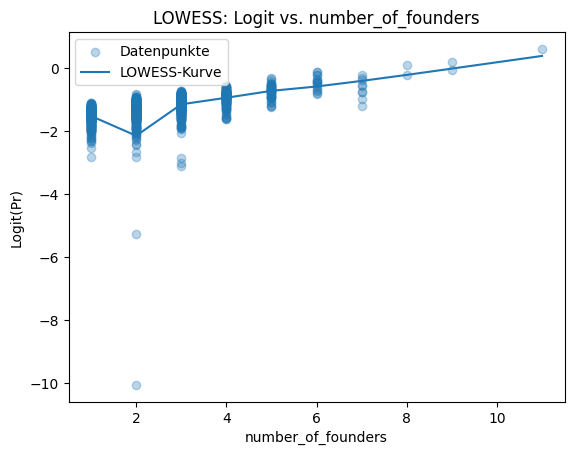

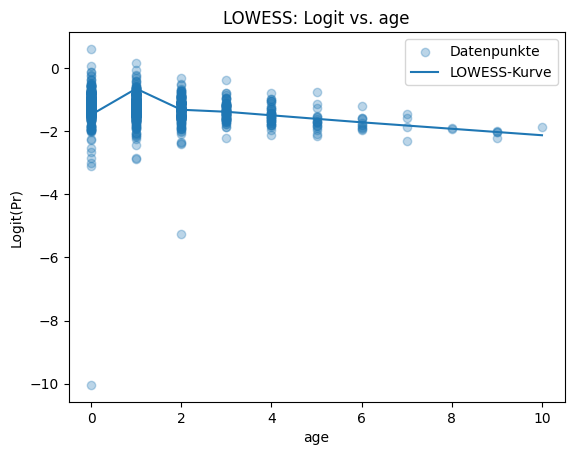

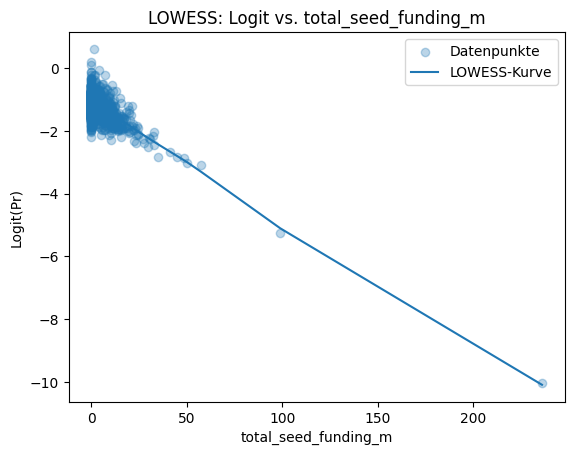

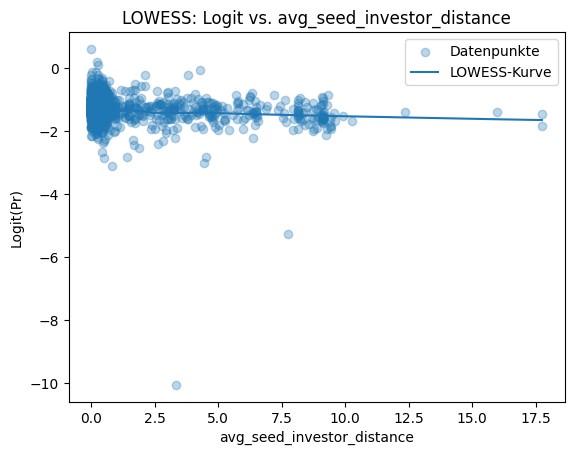

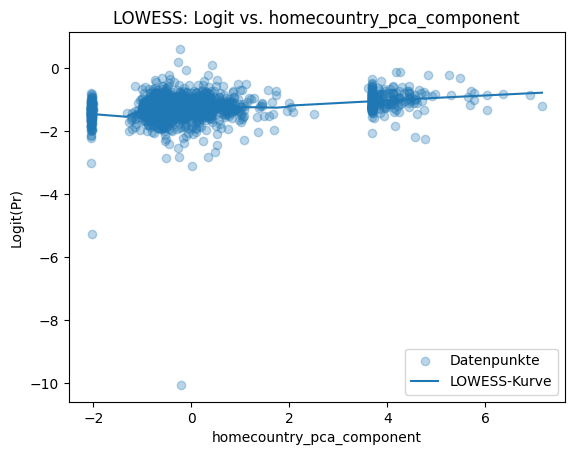

In [1599]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

df = data.copy()

# Stelle sicher, dass 'success' als 0/1 kodiert ist, z.B.:
# data['success'] = data['success'].map({False:0, True:1})
df['exit_binary'] = df['exit_binary'].astype(int)
# Liste der kontinuierlichen Prädiktoren
continuous_vars = [
    'number_of_founders',
    'age',
    'total_seed_funding_m',
    'avg_seed_investor_distance',
    'homecountry_pca_component'
]

# 1) Box‐Tidwell‐Ansatz: Prädiktor × log(Prädiktor)
for var in continuous_vars:
    df[f'log_{var}'] = np.log(df[var] + 1e-6)
    df[f'{var}_x_log_{var}'] = df[var] * df[f'log_{var}']

# Logistisches Modell mit allen Interaktionstermen
formula_bt = 'exit_binary ~ ' + ' + '.join(
    [f"{var} + {var}_x_log_{var}" for var in continuous_vars]
)
model_bt = smf.logit(formula_bt, data=df).fit(disp=False)
print(model_bt.summary())

# 2) LOWESS‐Diagnose für jeden Prädiktor
# Basis‐Modell ohne die Log‐Interaktionen
formula_base = 'exit_binary ~ ' + ' + '.join(continuous_vars)
model_base = smf.logit(formula_base, data=df).fit(disp=False)

# Gefittete Wahrscheinlichkeiten und Logits berechnen
df['fitted'] = model_base.predict()
df['logit']  = np.log(df['fitted'] / (1 - df['fitted']))

# Lowess‐Plots erstellen
for var in continuous_vars:
    smoothed = lowess(
        endog=df['logit'],
        exog=df[var],
        frac=0.3,
        it=0
    )
    plt.figure()
    plt.scatter(df[var], df['logit'], alpha=0.3, label='Datenpunkte')
    plt.plot(smoothed[:, 0], smoothed[:, 1], label='LOWESS-Kurve')
    plt.xlabel(var)
    plt.ylabel('Logit(Pr)')
    plt.title(f'LOWESS: Logit vs. {var}')
    plt.legend()
    plt.show()

                            OLS Regression Results                            
Dep. Variable:      log_years_to_exit   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     3.592
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           2.85e-06
Time:                        22:59:44   Log-Likelihood:                -276.39
No. Observations:                 356   AIC:                             588.8
Df Residuals:                     338   BIC:                             658.5
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

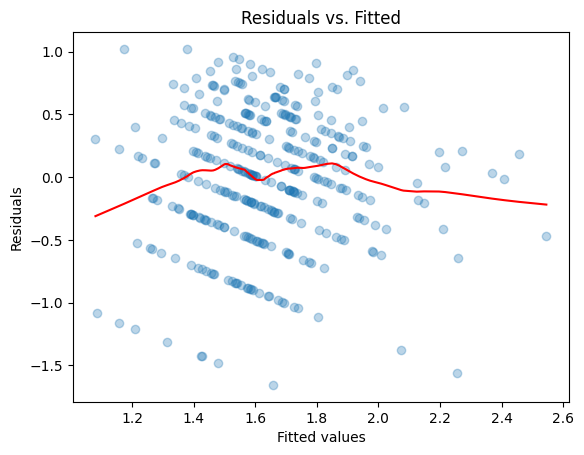

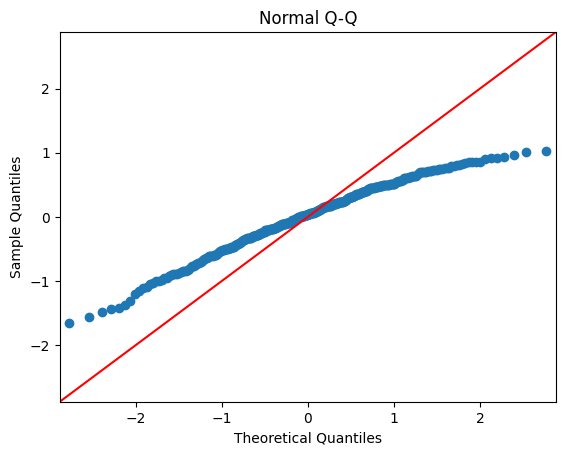

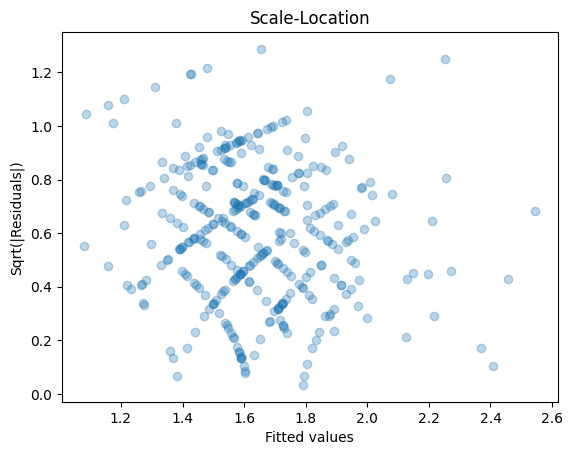

                          Variable        VIF
0                        Intercept  44.638608
1               hub_binary[T.True]   1.119127
2               b2b_binary[T.True]   1.310446
3                   energy[T.True]   2.680868
4                materials[T.True]   1.351720
5              industrials[T.True]   1.123793
6   consumer_discretionary[T.True]   1.160925
7         consumer_staples[T.True]   1.104306
8              health_care[T.True]   1.158203
9               financials[T.True]   1.217212
10  information_technology[T.True]   1.276493
11  communication_services[T.True]   1.187056
12               utilities[T.True]   2.547285
13             real_estate[T.True]   1.033791
14                   other[T.True]   1.084614
15                closeness_global   1.067281
16              number_of_founders   1.117812
17                             age   1.058084


In [1600]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt


data['log_years_to_exit'] = np.log(data['years_to_exit'])

# 2) Kontinuierliche Zielvariable definieren
dv = 'log_years_to_exit'

# 3) Liste der Prädiktoren
predictors = [
  "closeness_global",
  "number_of_founders",
  "age",
  "headquarters_country", "hub_binary", "b2b_binary",
  "energy", "materials", "industrials", "consumer_discretionary",
  "consumer_staples", "health_care", "financials",
  "information_technology", "communication_services",
  "utilities", "real_estate", "other"
]

# 4) Lineares Modell (OLS) fitten
formula = dv + ' ~ ' + ' + '.join(predictors)
model_linear = smf.ols(formula, data=data).fit()
print(model_linear.summary())

# 5) Residual-Diagnostik

# Residuen und gefittete Werte
resid = model_linear.resid
fitted = model_linear.fittedvalues

# 5a) Residuals vs. Fitted (Linearity & Homoskedastizität)
smoothed = lowess(resid, fitted, frac=0.3)
plt.figure()
plt.scatter(fitted, resid, alpha=0.3)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

# 5b) Q-Q-Plot (Normalität der Residuen)
sm.qqplot(resid, line='45')
plt.title('Normal Q-Q')
plt.show()

# 5c) Scale-Location (Homoskedastizität)
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.3)
plt.xlabel('Fitted values')
plt.ylabel('Sqrt(|Residuals|)')
plt.title('Scale-Location')
plt.show()

# 6) Multikollinearitäts-Check (VIF)
X = model_linear.model.exog
vif = pd.DataFrame({
    'Variable': model_linear.model.exog_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif)

Add dummy for network

In [1601]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

closeness_homecountry    0
dtype: int64
Anzahl Null-Werte: 87 (5.6%)


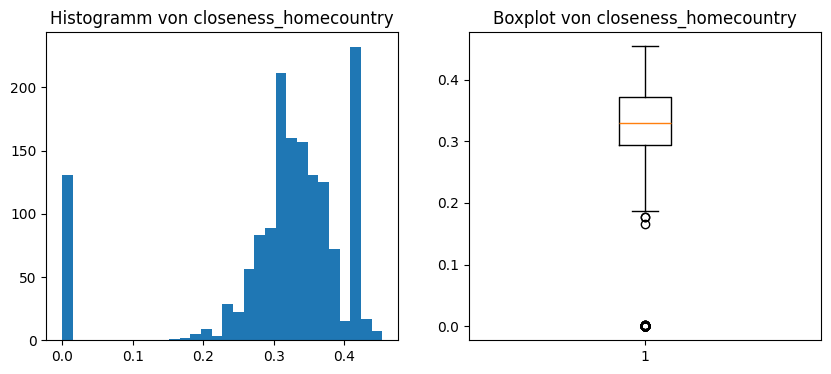

In [1602]:
df = data.copy()
# 1.1 fehlende Werte
print(df[['closeness_homecountry']].isna().sum())

# 1.2 Null-Massen
n_zero = (df['closeness_homecountry'] == 0).sum()
print(f"Anzahl Null-Werte: {n_zero} ({n_zero/len(df):.1%})")

# 1.3 Histogramm & Boxplot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['closeness_homecountry'], bins=30)
plt.title("Histogramm von closeness_homecountry")
plt.subplot(1,2,2)
plt.boxplot(df['closeness_homecountry'])
plt.title("Boxplot von closeness_homecountry")
plt.show()

In [1603]:
data['closeness_homecountry_zero'] = (data['closeness_homecountry'] == 0).astype(int)
data['closeness_homecountry_positive'] = data['closeness_homecountry'].clip(lower=0)

data['closeness_global_zero'] = (data['closeness_global'] == 0).astype(int)
data['closeness_global_positive'] = data['closeness_global'].clip(lower=0)

In [1604]:
data.to_csv('data/sets-for-r/regression_data.csv', index=False)

In [1605]:
# Define the subset of variables for correlation analysis
subset_variables = [
    'seed_investor_same_city',
    'seed_investors_all_same_country'
]

# Calculate the correlation matrix
correlation_matrix = data[subset_variables].corr()

# Display the correlation matrix
print(correlation_matrix)

                                 seed_investor_same_city  \
seed_investor_same_city                         1.000000   
seed_investors_all_same_country                -0.137851   

                                 seed_investors_all_same_country  
seed_investor_same_city                                -0.137851  
seed_investors_all_same_country                         1.000000  
